<a href="https://colab.research.google.com/github/jonathancdelc/com-90505-jonathancdelc/blob/main/Practica_1_Data_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
!pip install duckdb --quiet

In [21]:
import pandas as pd

url_pedidos = 'https://raw.githubusercontent.com/jonathancdelc/com-90505-jonathancdelc/refs/heads/main/pedidos.csv'
pedidos = pd.read_csv(url_pedidos)

url_clientes = 'https://raw.githubusercontent.com/jonathancdelc/com-90505-jonathancdelc/refs/heads/main/table.csv'
clientes = pd.read_csv(url_clientes)

print("¡Datasets cargados y nombrados con éxito!")

¡Datasets cargados y nombrados con éxito!


In [22]:
print("--- Columnas de la tabla 'pedidos' ---")
print(pedidos.columns.tolist())

print("\n--- Columnas de la tabla 'clientes' ---")
print(clientes.columns.tolist())

--- Columnas de la tabla 'pedidos' ---
['pedido_id', 'cliente_id', 'fecha_compra', 'monto']

--- Columnas de la tabla 'clientes' ---
['cliente_id', 'nombre', 'edad', 'region']


In [23]:
print("=== AUDITORÍA DE TIPOS: TABLA PEDIDOS ===")
pedidos.info()

=== AUDITORÍA DE TIPOS: TABLA PEDIDOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pedido_id     500 non-null    int64  
 1   cliente_id    500 non-null    int64  
 2   fecha_compra  500 non-null    object 
 3   monto         494 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 15.8+ KB


In [24]:
print("=== AUDITORÍA DE TIPOS: TABLA CLIENTES ===")
clientes.info()

=== AUDITORÍA DE TIPOS: TABLA CLIENTES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   cliente_id  200 non-null    int64  
 1   nombre      200 non-null    object 
 2   edad        169 non-null    float64
 3   region      160 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.4+ KB


In [25]:
print("=== PORCENTAJE DE NULOS: TABLA PEDIDOS ===")
porcentaje_nulos_pedidos = pedidos.isnull().mean() * 100
print(porcentaje_nulos_pedidos)

=== PORCENTAJE DE NULOS: TABLA PEDIDOS ===
pedido_id       0.0
cliente_id      0.0
fecha_compra    0.0
monto           1.2
dtype: float64


In [26]:
print("=== PORCENTAJE DE NULOS: TABLA CLIENTES ===")
porcentaje_nulos_clientes = clientes.isnull().mean() * 100
print(porcentaje_nulos_clientes)

=== PORCENTAJE DE NULOS: TABLA CLIENTES ===
cliente_id     0.0
nombre         0.0
edad          15.5
region        20.0
dtype: float64


In [27]:
print("=== ESTADÍSTICAS GLOBALES: MONTO DE PEDIDOS ===")
# Reemplaza 'monto' si tu columna se llama de otra forma (ej. 'gasto', 'total')
pedidos['monto'].describe()

=== ESTADÍSTICAS GLOBALES: MONTO DE PEDIDOS ===


,monto
count,4.940000e+02
mean,3.296813e+03
std,6.747660e+04
min,-5.000000e+01
25%,1.432022e+02
50%,2.666495e+02
75%,3.832233e+02
max,1.500000e+06


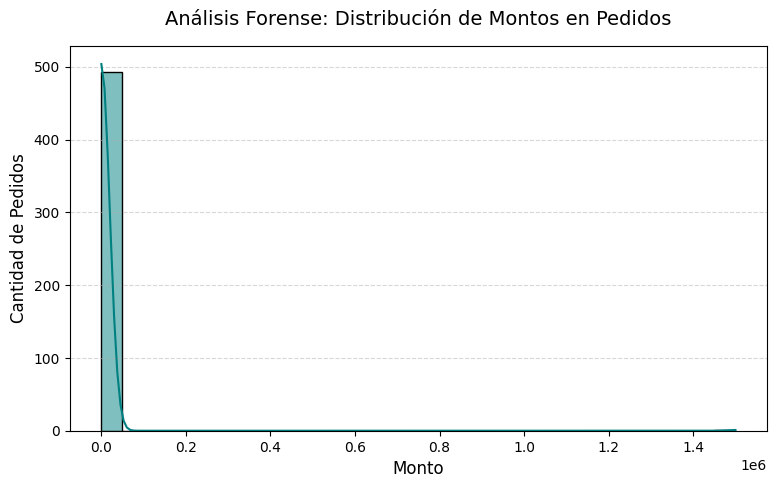

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
# Volvemos a usar la columna 'monto' de la tabla pedidos
sns.histplot(pedidos['monto'], kde=True, color='teal', bins=30)

plt.title('Análisis Forense: Distribución de Montos en Pedidos', fontsize=14, pad=15)
plt.xlabel('Monto', fontsize=12)
plt.ylabel('Cantidad de Pedidos', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [33]:
# ==========================================
# LIMPIEZA DE LA TABLA 'PEDIDOS' (SOLUCIÓN DEFINITIVA)
# ==========================================

# Usamos format='mixed' para que procese tanto las fechas con guiones como con barras automáticamente
pedidos['fecha_compra'] = pd.to_datetime(pedidos['fecha_compra'], format='mixed')

# Filtrar Outliers y Errores (Mantenemos montos lógicos)
pedidos_limpio = pedidos[(pedidos['monto'] > 0) & (pedidos['monto'] < 10000)].copy()

# Eliminar nulos remanentes en monto si los hay
pedidos_limpio.dropna(subset=['monto'], inplace=True)


# ==========================================
# LIMPIEZA DE LA TABLA 'CLIENTES'
# ==========================================

clientes_limpio = clientes.copy()

# Imputar nulos en Región con un valor genérico
clientes_limpio['region'] = clientes_limpio['region'].fillna('No Especificada')

# Imputar nulos en Edad con la mediana
clientes_limpio['edad'] = clientes_limpio['edad'].fillna(clientes_limpio['edad'].median())

print("¡Limpieza ejecutada con éxito!")
print(f"Pedidos originales: {len(pedidos)} -> Pedidos limpios: {len(pedidos_limpio)}")

¡Limpieza ejecutada con éxito!
Pedidos originales: 500 -> Pedidos limpios: 492


In [34]:
import duckdb

# =====================================================================
# EJERCICIO 1: SELECCIÓN SELECTIVA Y EJERCICIO 2: FILTRADO TEMPORAL
# =====================================================================
# Extraemos solo las columnas solicitadas del último trimestre de 2026.

query_seleccion_y_filtro = """
    SELECT
        cliente_id,
        fecha_compra,
        monto
    FROM pedidos_limpio
    WHERE fecha_compra >= '2026-04-01'
      AND fecha_compra <= '2026-06-30'
    ORDER BY fecha_compra DESC;
"""

print("--- 1 y 2. Selección Selectiva y Filtrado Temporal (Último Trimestre 2026) ---")
df_trimestre = duckdb.query(query_seleccion_y_filtro).df()
display(df_trimestre.head(10))


# =====================================================================
# EJERCICIO 3: ENRIQUECIMIENTO (INNER JOIN)
# =====================================================================
# Cruzamos ambas tablas por 'cliente_id' para traer el nombre, región y gasto.

query_join = """
    SELECT
        p.cliente_id,
        c.nombre,
        c.region,
        p.fecha_compra,
        p.monto
    FROM pedidos_limpio p
    INNER JOIN clientes_limpio c
        ON p.cliente_id = c.cliente_id
    ORDER BY p.fecha_compra DESC;
"""

print("\n--- 3. Enriquecimiento mediante INNER JOIN ---")
df_enriquecido = duckdb.query(query_join).df()
display(df_enriquecido.head(10))


# =====================================================================
# EJERCICIO 4: AGREGACIÓN DE VALOR (GROUP BY)
# =====================================================================
# Agrupamos por cliente para calcular su total gastado.
# Ordenamos de mayor a menor para encontrar a los usuarios más valiosos (VIP).

query_agregacion = """
    SELECT
        c.cliente_id,
        c.nombre,
        c.region,
        SUM(p.monto) AS total_gastado,
        COUNT(p.pedido_id) AS cantidad_pedidos
    FROM clientes_limpio c
    INNER JOIN pedidos_limpio p
        ON c.cliente_id = p.cliente_id
    GROUP BY c.cliente_id, c.nombre, c.region
    ORDER BY total_gastado DESC;
"""

print("\n--- 4. Agregación de Valor: Total Gastado por Cliente (Usuarios VIP) ---")
df_clientes_vip = duckdb.query(query_agregacion).df()
display(df_clientes_vip.head(10))

--- 1 y 2. Selección Selectiva y Filtrado Temporal (Último Trimestre 2026) ---


,cliente_id,fecha_compra,monto



--- 3. Enriquecimiento mediante INNER JOIN ---


,cliente_id,nombre,region,fecha_compra,monto
0,25,Cliente_25,Oeste,2025-11-01,378.6780
1,55,Cliente_55,Oeste,2025-09-01,74.8153
2,63,Cliente_63,Oeste,2025-07-02,492.8300
3,61,Cliente_61,Sur,2025-06-01,245.6100
4,121,Cliente_121,Sur,2025-06-01,266.0340
5,30,Cliente_30,Sur,2025-03-25,348.3750
6,162,Cliente_162,Norte,2025-03-24,167.1150
7,51,Cliente_51,Oeste,2025-03-23,320.2180
8,155,Cliente_155,Norte,2025-03-22,269.8300
9,25,Cliente_25,Oeste,2025-03-22,237.0570



--- 4. Agregación de Valor: Total Gastado por Cliente (Usuarios VIP) ---


,cliente_id,nombre,region,total_gastado,cantidad_pedidos
0,145,Cliente_145,Norte,2743.7561,10
1,47,Cliente_47,Norte,1954.4390,7
2,151,Cliente_151,Oeste,1917.3560,6
3,133,Cliente_133,Norte,1757.0020,5
4,39,Cliente_39,Norte,1745.0400,5
5,14,Cliente_14,Oeste,1679.9333,5
6,56,Cliente_56,Norte,1648.0610,5
7,132,Cliente_132,No Especificada,1598.4360,5
8,173,Cliente_173,Oeste,1570.2410,5
9,74,Cliente_74,Norte,1552.0680,4


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [35]:
# Realizamos la imputación usando la mediana
clientes['edad_imputada'] = clientes['edad'].fillna(clientes['edad'].median())

print(f"Mediana calculada para la edad: {clientes['edad'].median()}")
print(f"Nulos restantes en edad: {clientes['edad_imputada'].isnull().sum()}")

Mediana calculada para la edad: 50.0
Nulos restantes en edad: 0


🧠 **Justificación del uso de la Mediana vs. Media:**
La mediana es una medida estadística robusta, lo que significa que no se ve afectada por los valores extremos (outliers). Por ejemplo, si en tu dataset tuvieras un error y la edad de un cliente fuera 200 años, la media (promedio) se elevaría artificialmente, haciendo que imputemos edades de 45 o 50 años a personas jóvenes. La mediana, al ser simplemente el valor central que divide los datos al 50%, ignora completamente la magnitud de esos extremos, garantizando que el valor imputado sea representativo de la realidad del negocio.

In [36]:
# Convertimos la columna al tipo de dato datetime de forma segura
pedidos['fecha_compra'] = pd.to_datetime(pedidos['fecha_compra'], format='mixed')

print(f"Nuevo tipo de dato de fecha_compra: {pedidos['fecha_compra'].dtype}")

Nuevo tipo de dato de fecha_compra: datetime64[ns]


In [37]:
import numpy as np

# 1. Calculamos los cuartiles Q1 (percentil 25) y Q3 (percentil 75)
Q1 = pedidos['monto'].quantile(0.25)
Q3 = pedidos['monto'].quantile(0.75)

# 2. Calculamos el Rango Intercuartílico (IQR)
IQR = Q3 - Q1

# 3. Definimos los límites estadísticos permitidos
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Rango Intercuartílico (IQR): {IQR}")
print(f"Límite Inferior Estadístico: {limite_inferior}")
print(f"Límite Superior Estadístico: {limite_superior}")

# 4. Aplicar la Acción: Filtrado y eliminación
# Decisión: Eliminamos porque los montos negativos y el valor de 1.5M tienen toda la firma de ser errores de sistema (fat-finger errors)
pedidos_final = pedidos[(pedidos['monto'] >= 0) & (pedidos['monto'] <= limite_superior)].copy()

print(f"\nRegistros antes del IQR: {len(pedidos)}")
print(f"Registros después de aplicar IQR (sin outliers ni negativos): {len(pedidos_final)}")

Rango Intercuartílico (IQR): 240.02100000000002
Límite Inferior Estadístico: -216.82925000000006
Límite Superior Estadístico: 743.2547500000001

Registros antes del IQR: 500
Registros después de aplicar IQR (sin outliers ni negativos): 492


**📢 Justificación de la Acción (Eliminar en lugar de Truncar):**
En este escenario, la mejor decisión es eliminar los registros atípicos. Un monto de -50 es imposible en una compra normal y representa un error de registro. Por otro lado, el monto de 1,500,000 frente a un tercer cuartil de apenas 383 es tan desproporcionadamente masivo que distorsiona por completo cualquier métrica o modelo predictivo que intentes construir. Al no reflejar el comportamiento habitual de tus clientes, truncarlo convertir el millón y medio a, por ejemplo, 740 seguiría inventando un dato falso. Removerlo limpia la base para un análisis real.